# Working with Entities

This tutorial covers all entity types in EDA-Schema, their relationships, graph structures, image attributes, and available methods. Entities are the core data structures that represent circuit components, metrics, and design information.

## What you'll learn

This tutorial covers:
- Create and work with all entity types (tabular, graph, metrics, flow)
- Understand entity relationships and hierarchies
- Work with graph structures (Netlist, ClockTree, TimingPath)
- Use Image2D attributes and visualization
- Apply entity methods (get_tabular_data, get_graph_data, plot, etc.)
- Navigate entity relationships and dependencies

## Requirements

- Completed Tutorial 1: Getting Started
- EDA-schema installed
- Basic understanding of Python dataclasses and NetworkX graphs

## See also

- **Python Examples**: `examples/02_entities/`
- **Entity Reference**: `docs/reference/entity_reference.md`

In [1]:
# Import EDA-schema and required libraries
from eda_schema import entity
from eda_schema.base import Image2D
import numpy as np
import matplotlib.pyplot as plt

print("EDA-schema imported successfully!")
print(f"Available entity types: {len([x for x in dir(entity) if 'Entity' in x])}")


EDA-schema imported successfully!
Available entity types: 21


## Entity Hierarchy and Organization

EDA-Schema organizes entities into several categories:

1. **Flow/Stage Entities**: DesignFlow, Constraint, DesignStage
2. **Tabular Entities**: Gate, Port, Pin, Net, StandardCell
3. **Graph Entities**: Netlist, ClockTree, TimingPath
4. **Metrics Entities**: Area, Power, Timing, Cell, Routability
5. **Timing Arc Entities**: NetArc, CellArc
6. **Special Entities**: PDN (Power Delivery Network)

### Entity Relationships

```
DesignFlow
  ├── ConstraintEntity (design constraints)
  └── DesignStageEntity (per stage)
      ├── NetlistEntity (graph: GATE, PORT, PIN, NET)
      │   ├── ClockTreeEntity (graph: clock distribution)
      │   ├── TimingPathEntity (graph: PIN, PORT, CELL_ARC, NET_ARC)
      │   └── PDNEntity (power distribution)
      ├── CellMetricsEntity
      ├── AreaMetricsEntity
      ├── PowerMetricsEntity
      ├── TimingMetricsEntity
      └── RoutabilityMetricsEntity
```

Exploring each category in detail.


## Part 1: Flow and Stage Entities

These entities organize the design flow hierarchy.

### DesignFlowEntity

Represents a complete RTL-to-GDSII execution with metadata and stages.


In [2]:
# Create a design flow
design_flow = entity.DesignFlowEntity(
    flow_id='example_flow',
    design='gcd',
    run_status='completed'
)

print(f"Created DesignFlow: {design_flow.flow_id}")
print(f"   Design: {design_flow.design}")
print(f"   Status: {design_flow.run_status}")
print(f"   Stages: {list(design_flow.stages.keys())} (empty initially)")


Created DesignFlow: example_flow
   Design: gcd
   Status: completed
   Stages: [] (empty initially)


### ConstraintEntity

Defines timing and physical constraints for the design.


In [3]:
# Create design constraints
constraints = entity.ConstraintEntity(
    flow_id='example_flow',
    clock_period=10.0,  # ns
    input_delay=2.0,    # ns
    output_delay=3.0,   # ns
    aspect_ratio=1.0,
    core_utilization=0.8
)

print(f"Created Constraints:")
print(f"   Clock period: {constraints.clock_period} ns")
print(f"   Input delay: {constraints.input_delay} ns")
print(f"   Output delay: {constraints.output_delay} ns")
print(f"   Core utilization: {constraints.core_utilization:.0%}")

# Link constraints to design flow
design_flow.constraints = constraints
print(f"\nLinked constraints to design flow")


Created Constraints:
   Clock period: 10.0 ns
   Input delay: 2.0 ns
   Output delay: 3.0 ns
   Core utilization: 80%

Linked constraints to design flow


### DesignStageEntity

Represents a single stage in the design flow, containing netlist and metrics.


In [4]:
# Create a design stage
design_stage = entity.DesignStageEntity(
    flow_id='example_flow',
    stage='floorplan',
    run_status='completed'
)

print(f"Created DesignStage: {design_stage.flow_id} / {design_stage.stage}")
print(f"   Status: {design_stage.run_status}")
print(f"   Netlist: {'Present' if design_stage.netlist else 'None'}")
print(f"   Metrics: {sum([1 for m in [design_stage.cell_metrics, design_stage.area_metrics, design_stage.power_metrics, design_stage.timing_metrics, design_stage.routability_metrics] if m is not None])} metrics attached")

# Link stage to design flow
design_flow.stages['floorplan'] = design_stage
print(f"\nLinked stage to design flow")
print(f"   Design flow now has {len(design_flow.stages)} stage(s)")


Created DesignStage: example_flow / floorplan
   Status: completed
   Netlist: None
   Metrics: 0 metrics attached

Linked stage to design flow
   Design flow now has 1 stage(s)


## Part 2: Tabular Entities

**Tabular entities** are simple data structures that store attributes without graph connectivity. They include:
- `GateEntity` - Logic gates/cells
- `PortEntity` - I/O ports
- `PinEntity` - Pins on gates
- `NetEntity` - Wires/nets connecting components
- `StandardCellEntity` - Standard cell library entries

These entities are stored as table rows in the database and can be queried independently.

### Creating Tabular Entities


In [5]:
# Create a standard cell first (gates reference these)
nand2_cell = entity.StandardCellEntity(
    name='NAND2_X1',
    width=0.5,
    height=2.0,
    no_of_input_pins=2,
    no_of_output_pins=1,
    is_sequential=False,
    is_inverter=False,
    is_buffer=False,
    is_filler=False,
    is_diode=False,
)

# Create a gate entity
gate = entity.GateEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='U1',
    standard_cell='NAND2_X1',  # References standard cell
    x_min=10.0,
    y_min=20.0,
    x_max=15.0,
    y_max=25.0,
    no_of_inputs=2,
    no_of_outputs=1
)

# Create I/O ports
input_port = entity.PortEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='clk',
    direction='INPUT',
    x=0.0,
    y=0.0
)

output_port = entity.PortEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='data_out',
    direction='OUTPUT',
    x=100.0,
    y=0.0
)

# Create pins for the gate
input_pin = entity.PinEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='U1/A',
    direction='INPUT',
    is_startpoint=False,
    is_endpoint=False,
    x_min=10.0,
    y_min=20.0,
    x_max=12.0,
    y_max=22.0
)

output_pin = entity.PinEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='U1/Y',
    direction='OUTPUT',
    is_startpoint=True,
    is_endpoint=False,
    x_min=13.0,
    y_min=20.0,
    x_max=15.0,
    y_max=22.0
)

# Create a net
net = entity.NetEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='net1',
    is_special_net=False,
    no_of_fanouts=2,
    x_min=0.0,
    y_min=0.0,
    x_max=100.0,
    y_max=100.0,
    length=50.0
)

print("Created tabular entities:")
print(f"   Standard Cell: {nand2_cell.name} ({nand2_cell.width}x{nand2_cell.height})")
print(f"   Gate: {gate.name} (uses {gate.standard_cell})")
print(f"   Ports: {input_port.name} ({input_port.direction}), {output_port.name} ({output_port.direction})")
print(f"   Pins: {input_pin.name}, {output_pin.name}")
print(f"   Net: {net.name} (fanouts: {net.no_of_fanouts})")


Created tabular entities:
   Standard Cell: NAND2_X1 (0.5x2.0)
   Gate: U1 (uses NAND2_X1)
   Ports: clk (INPUT), data_out (OUTPUT)
   Pins: U1/A, U1/Y
   Net: net1 (fanouts: 2)


### Entity Methods: Working with Tabular Data

All entities inherit from `BaseEntity` and provide methods for data extraction:

- `get_tabular_data()`: Returns dictionary of tabular fields (for database storage)
- `get_image_data()`: Returns dictionary of Image2D fields
- `validate()`: Validates entity types and constraints


In [6]:
# Demonstrate entity methods
print("=== Entity Methods ===")

# 1. get_tabular_data() - Extract tabular fields
tabular_data = gate.get_tabular_data()
print(f"\n1. get_tabular_data() for GateEntity:")
print(f"   Primary keys: {list([k for k, v in tabular_data.items() if 'flow_id' in k or 'stage' in k or 'name' in k])}")
print(f"   Total tabular fields: {len(tabular_data)}")
print(f"   Sample: {dict(list(tabular_data.items())[:3])}")

# 2. get_image_data() - Extract Image2D fields (if any)
image_data = gate.get_image_data()
print(f"\n2. get_image_data() for GateEntity:")
print(f"   Image fields: {list(image_data.keys())} (GateEntity has no images)")

# 3. Entity representation
print(f"\n3. Entity string representation:")
print(f"   {gate}")

# 4. Validate entity
print(f"\n4. validate() - Type checking:")
gate.validate()  # Validates all field types
print("   Gate entity is valid")


=== Entity Methods ===

1. get_tabular_data() for GateEntity:
   Primary keys: ['flow_id', 'stage', 'name']
   Total tabular fields: 10
   Sample: {'flow_id': 'example_flow', 'stage': 'floorplan', 'name': 'U1'}

2. get_image_data() for GateEntity:
   Image fields: [] (GateEntity has no images)

3. Entity string representation:
   GateEntity({'flow_id': 'example_flow', 'stage': 'floorplan', 'name': 'U1', 'standard_cell': 'NAND2_X1', 'x_min': 10.0, 'y_min': 20.0, 'x_max': 15.0, 'y_max': 25.0, 'no_of_inputs': 2, 'no_of_outputs': 1})

4. validate() - Type checking:
   Gate entity is valid


## Part 3: Graph Entities

**Graph entities** contain NetworkX graph structures representing connectivity. They include:
- `NetlistEntity`: Complete circuit netlist (GATE, PORT, PIN, NET nodes)
- `ClockTreeEntity`: Clock distribution network (similar structure to netlist)
- `TimingPathEntity`: Timing path graph (PIN, PORT, CELL_ARC, NET_ARC nodes)

**Key features:**
- Graph entities have `nodes` and `edges` properties
- Nodes store entity objects as attributes with `type` field
- Edges represent connections (e.g., net → gate, gate → net)
- Can traverse the graph using NetworkX methods
- Support `get_graph_data()` for serialization


### NetlistEntity: Complete Circuit Graph

A `NetlistEntity` is a graph that represents the complete circuit. It contains:
- **Nodes**: GATE, PORT, PIN, NET (with entity objects stored in node attributes)
- **Edges**: Connections between nodes (e.g., port → net → gate)
- **Image attributes**: cell_placement, routing, routing_by_metal
- **Related entities**: ClockTree, TimingPath, PDN, Metrics


In [7]:
# Create a netlist entity
netlist = entity.NetlistEntity(
    flow_id='example_flow',
    stage='floorplan',
    no_of_inputs=2,
    no_of_outputs=1,
    no_of_cells=3,
    no_of_nets=4,
    no_of_pins=6,
    utilization=0.5,
    width=100.0,
    height=100.0
)

print(f"Created NetlistEntity:")
print(f"   Flow ID: {netlist.flow_id}, Stage: {netlist.stage}")
print(f"   Statistics: {netlist.no_of_cells} cells, {netlist.no_of_nets} nets, {netlist.no_of_pins} pins")
print(f"   Utilization: {netlist.utilization:.2%}, Size: {netlist.width}x{netlist.height} um")
print(f"   Graph nodes: {len(netlist.nodes)}, Graph edges: {len(netlist.edges)}")
print(f"   Allowed node types: {list(netlist.NODE_TYPES.keys())}")


Created NetlistEntity:
   Flow ID: example_flow, Stage: floorplan
   Statistics: 3 cells, 4 nets, 6 pins
   Utilization: 50.00%, Size: 100.0x100.0 um
   Graph nodes: 0, Graph edges: 0
   Allowed node types: ['GATE', 'PORT', 'PIN', 'NET']


### Graph Methods: Adding Nodes and Edges

Graph entities provide methods for building and traversing graphs:

- `add_node(node_id, type=..., entity=...)`: Add a node with type and entity
- `add_edge(u, v)`: Add an edge from node u to node v
- `predecessors(node)`: Get nodes that connect to this node
- `successors(node)`: Get nodes this node connects to
- `bfs_traverse(node, ...)`: Breadth-first traversal
- `get_graph_data()`: Serialize graph to dictionary


In [8]:
# Add nodes to the netlist graph
# Each node has a type (GATE, PORT, PIN, NET) and stores an entity object

# Add port nodes
netlist.add_node('clk', type='PORT', entity=input_port)
netlist.add_node('data_out', type='PORT', entity=output_port)

# Add gate nodes (using the gate we created earlier)
netlist.add_node('U1', type='GATE', entity=gate)

# Add more gates
for i in range(2, 4):
    gate_i = entity.GateEntity(
        flow_id='example_flow',
        stage='floorplan',
        name=f'U{i}',
        standard_cell='NAND2_X1',
        x_min=10.0 + i * 20.0,
        y_min=10.0,
        x_max=15.0 + i * 20.0,
        y_max=15.0,
        no_of_inputs=2,
        no_of_outputs=1
    )
    netlist.add_node(f'U{i}', type='GATE', entity=gate_i)

# Add pin nodes
netlist.add_node('U1/A', type='PIN', entity=input_pin)
netlist.add_node('U1/Y', type='PIN', entity=output_pin)

# Add net nodes
netlist.add_node('net1', type='NET', entity=net)

print(f"Added nodes to netlist graph:")
print(f"   Total nodes: {len(netlist.nodes)}")
print(f"   Node types: {set([netlist.nodes[n].get('type') for n in netlist.nodes])}")


Added nodes to netlist graph:
   Total nodes: 8
   Node types: {'GATE', 'PORT', 'NET', 'PIN'}


### Building Graph Connectivity

Edges represent signal flow in the circuit:
- `port → net`: Port drives a net
- `net → gate/pin`: Net connects to gate inputs
- `gate/pin → net`: Gate outputs drive nets
- `net → port`: Net connects to output port

Edges are directed, representing signal propagation direction.


In [9]:
# Add edges to represent circuit connectivity
# Clock port drives net1
netlist.add_edge('clk', 'net1')
print("clk (PORT) → net1 (NET)")

# Net1 connects to gate U1 input pin
netlist.add_edge('net1', 'U1/A')
print("net1 (NET) → U1/A (PIN)")

# Gate U1 output pin drives net2
netlist.add_edge('U1/Y', 'net2')
print("U1/Y (PIN) → net2 (NET)")

# Connect net2 to next gate
netlist.add_edge('net2', 'U2')
print("net2 (NET) → U2 (GATE)")

# Final net connects to output port
netlist.add_edge('net3', 'data_out')
print("net3 (NET) → data_out (PORT)")

print(f"\nGraph structure:")
print(f"   Total nodes: {len(netlist.nodes)}")
print(f"   Total edges: {len(netlist.edges)}")
print(f"   Edges: {list(netlist.edges)}")


clk (PORT) → net1 (NET)
net1 (NET) → U1/A (PIN)
U1/Y (PIN) → net2 (NET)
net2 (NET) → U2 (GATE)
net3 (NET) → data_out (PORT)

Graph structure:
   Total nodes: 10
   Total edges: 5
   Edges: [('clk', 'net1'), ('U1/Y', 'net2'), ('net1', 'U1/A'), ('net2', 'U2'), ('net3', 'data_out')]


### Graph Traversal Methods

Graph entities support NetworkX traversal methods:
- `predecessors(node)`: Get nodes that connect TO this node (fanin)
- `successors(node)`: Get nodes this node connects TO (fanout)
- `bfs_traverse(node, fanin=True, fanout=True, depth_limit=-1)`: Breadth-first search
- `get_graph_data()`: Serialize graph structure to dictionary


In [10]:
# Analyze graph structure
print("=== Graph Analysis ===")

# Count nodes by type
node_counts = {}
for node_id, node_data in netlist.nodes(data=True):
    node_type = node_data.get('type', 'UNKNOWN')
    node_counts[node_type] = node_counts.get(node_type, 0) + 1

print("\n1. Node counts by type:")
for node_type, count in sorted(node_counts.items()):
    print(f"   {node_type}: {count}")

# Show connectivity using graph methods
print("\n2. Connectivity (using predecessors/successors):")
for node_id in ['clk', 'net1', 'U1']:
    if node_id in netlist.nodes:
        preds = list(netlist.predecessors(node_id))
        succs = list(netlist.successors(node_id))
        print(f"   {node_id} ({netlist.nodes[node_id].get('type')}):")
        if preds:
            print(f"      ← {preds} (fanin)")
        if succs:
            print(f"      → {succs} (fanout)")

# BFS traversal example
print("\n3. BFS Traversal from 'clk':")
visited = netlist.bfs_traverse('clk', fanin=False, fanout=True, depth_limit=3)
print(f"   Visited nodes: {visited}")

# Get graph data for serialization
print("\n4. get_graph_data() - Serialize graph:")
graph_data = netlist.get_graph_data()
print(f"   Nodes: {len(graph_data['nodes'])}")
print(f"   Edges: {len(graph_data['edges'])}")
print(f"   Sample edges: {graph_data['edges'][:3]}")


=== Graph Analysis ===

1. Node counts by type:
   GATE: 3
   NET: 1
   PIN: 2
   PORT: 2
   UNKNOWN: 2

2. Connectivity (using predecessors/successors):
   clk (PORT):
      → ['net1'] (fanout)
   net1 (NET):
      ← ['clk'] (fanin)
      → ['U1/A'] (fanout)
   U1 (GATE):

3. BFS Traversal from 'clk':
   Visited nodes: ['clk', 'net1', 'U1/A']

4. get_graph_data() - Serialize graph:
   Nodes: 10
   Edges: 5
   Sample edges: [['clk', 'net1'], ['U1/Y', 'net2'], ['net1', 'U1/A']]


### Linking Netlist to Design Stage

The netlist is linked to its design stage, which also contains metrics:


In [11]:
# Link netlist to design stage
design_stage.netlist = netlist
print("Linked NetlistEntity to DesignStageEntity")

# Show the relationship
print(f"\nEntity Relationships:")
print(f"   DesignFlow: {design_flow.flow_id}")
print(f"     └── DesignStage: {design_stage.stage}")
print(f"         ├── NetlistEntity: {design_stage.netlist.flow_id}/{design_stage.netlist.stage}")
print(f"         │   ├── Nodes: {len(design_stage.netlist.nodes)}")
print(f"         │   ├── Edges: {len(design_stage.netlist.edges)}")
print(f"         │   └── Images: {len([k for k, v in design_stage.netlist.get_image_data().items() if v is not None])}")
print(f"         └── Metrics: (to be added)")


Linked NetlistEntity to DesignStageEntity

Entity Relationships:
   DesignFlow: example_flow
     └── DesignStage: floorplan
         ├── NetlistEntity: example_flow/floorplan
         │   ├── Nodes: 10
         │   ├── Edges: 5
         │   └── Images: 0
         └── Metrics: (to be added)


## Part 4: Metrics Entities

**Metrics entities** store design quality metrics for each design stage. They are linked to `DesignStageEntity`:

- `CellMetricsEntity`: Cell count statistics by type
- `AreaMetricsEntity`: Area breakdown by component type
- `PowerMetricsEntity`: Power consumption breakdown
- `TimingMetricsEntity`: Timing performance metrics
- `RoutabilityMetricsEntity`: Routing quality metrics (with Image2D)


In [12]:
# Create all metrics entities
cell_metrics = entity.CellMetricsEntity(
    flow_id='example_flow',
    stage='floorplan',
    no_of_combinational_cells=100,
    no_of_sequential_cells=50,
    no_of_buffers=10,
    no_of_inverters=5,
    no_of_fillers=20,
    no_of_tap_cells=0,
    no_of_diodes=0,
    no_of_macros=0,
    no_of_total_cells=185
)

area_metrics = entity.AreaMetricsEntity(
    flow_id='example_flow',
    stage='floorplan',
    combinational_cell_area=100.0,
    sequential_cell_area=50.0,
    buffer_area=10.0,
    inverter_area=5.0,
    cell_area=165.0,
    filler_area=0,
    tap_cell_area=0,
    diode_area=0,
    macro_area=0,
    total_area=200.0
)

power_metrics = entity.PowerMetricsEntity(
    flow_id='example_flow',
    stage='floorplan',
    combinational_power=0.1,
    sequential_power=0.2,
    macro_power=0.05,
    internal_power=0.08,
    switching_power=0.07,
    leakage_power=0.01,
    total_power=0.51
)

timing_metrics = entity.TimingMetricsEntity(
    flow_id='example_flow',
    stage='floorplan',
    worst_slack=-0.5,
    total_negative_slack=10.0,
    worst_arrival_time=12.5,
    worst_required_time=12.0,
    critical_path_startpoint='clk',
    critical_path_endpoint='data_out',
    no_of_endpoints=50,
    no_of_violating_endpoints=5
)

# RoutabilityMetricsEntity with Image2D
rudy_array = np.random.rand(50, 50) * 0.1  # Simulated RUDY values
rudy_img = Image2D(rudy_array)

routability_metrics = entity.RoutabilityMetricsEntity(
    flow_id='example_flow',
    stage='floorplan',
    rudy_net=rudy_img,
    rudy_pin=Image2D(np.random.rand(50, 50) * 0.05)
)

print("Created all Metrics Entities:")
print(f"   CellMetrics: {cell_metrics.no_of_total_cells} total cells")
print(f"   AreaMetrics: {area_metrics.total_area} um² total area")
print(f"   PowerMetrics: {power_metrics.total_power} W total power")
print(f"   TimingMetrics: {timing_metrics.worst_slack} ns worst slack")
print(f"   RoutabilityMetrics: {len([k for k, v in routability_metrics.get_image_data().items() if v is not None])} RUDY images")

# Link all metrics to design stage
design_stage.cell_metrics = cell_metrics
design_stage.area_metrics = area_metrics
design_stage.power_metrics = power_metrics
design_stage.timing_metrics = timing_metrics
design_stage.routability_metrics = routability_metrics

print(f"\nLinked all metrics to DesignStageEntity")
print(f"   Design stage now has {sum([1 for m in [design_stage.cell_metrics, design_stage.area_metrics, design_stage.power_metrics, design_stage.timing_metrics, design_stage.routability_metrics] if m is not None])} metrics")


Created all Metrics Entities:
   CellMetrics: 185 total cells
   AreaMetrics: 200.0 um² total area
   PowerMetrics: 0.51 W total power
   TimingMetrics: -0.5 ns worst slack
   RoutabilityMetrics: 2 RUDY images

Linked all metrics to DesignStageEntity
   Design stage now has 5 metrics


### RoutabilityMetricsEntity: Image2D Example

RoutabilityMetricsEntity contains Image2D attributes for congestion visualization:


=== RoutabilityMetricsEntity Image2D ===
Available RUDY images: ['rudy_net', 'rudy_pin']


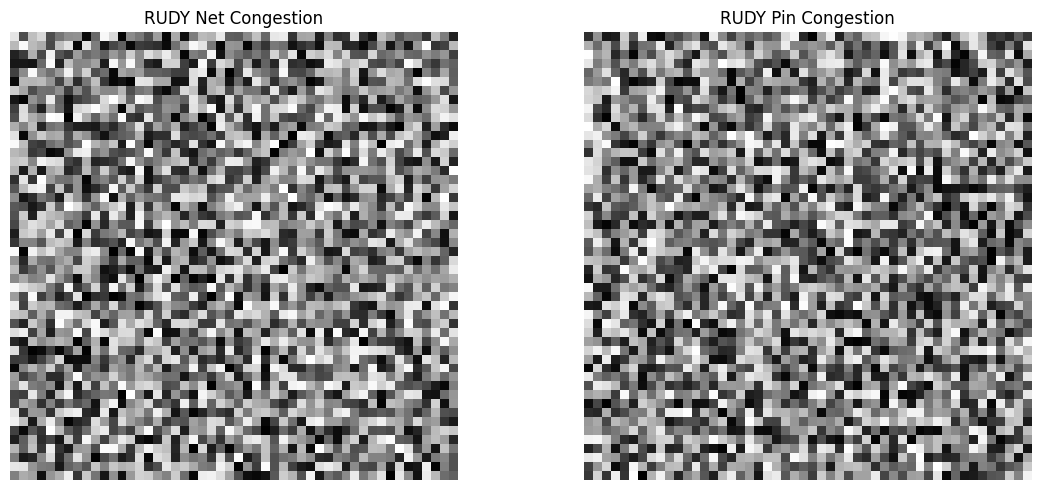


RoutabilityMetrics images visualized
   RUDY net shape: (50, 50)
   RUDY net range: [0.0000, 0.1000]


In [13]:
# Visualize RoutabilityMetrics images
print("=== RoutabilityMetricsEntity Image2D ===")

image_data = routability_metrics.get_image_data()
print(f"Available RUDY images: {[k for k, v in image_data.items() if v is not None]}")

if routability_metrics.rudy_net is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot RUDY net
    routability_metrics.rudy_net.plot(ax=axes[0], title="RUDY Net Congestion")
    
    # Plot RUDY pin
    if routability_metrics.rudy_pin is not None:
        routability_metrics.rudy_pin.plot(ax=axes[1], title="RUDY Pin Congestion")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRoutabilityMetrics images visualized")
    print(f"   RUDY net shape: {routability_metrics.rudy_net.shape}")
    print(f"   RUDY net range: [{routability_metrics.rudy_net.min():.4f}, {routability_metrics.rudy_net.max():.4f}]")


## Part 5: Timing Arc Entities

Timing arcs represent delay components in timing paths:
- `NetArcEntity`: Wire delay across a routed net
- `CellArcEntity`: Gate delay through a logic cell

These are used within `TimingPathEntity` graphs.


In [14]:
# Create timing arc entities
# Note: Timing arcs require startpoint, endpoint, and path_type as part of their primary key
# These identify which timing path the arc belongs to

net_arc = entity.NetArcEntity(
    flow_id='example_flow',
    stage='floorplan',
    startpoint='clk',  # Required: startpoint of the timing path
    endpoint='data_out',  # Required: endpoint of the timing path
    path_type='setup',  # Required: type of timing path (setup/hold)
    net_name='net1',
    delay=0.5,  # ns
    arrival_time=2.5,
    slew=0.1,
    capacitance=10.0  # fF
)

cell_arc = entity.CellArcEntity(
    flow_id='example_flow',
    stage='floorplan',
    startpoint='clk',  # Required: startpoint of the timing path
    endpoint='data_out',  # Required: endpoint of the timing path
    path_type='setup',  # Required: type of timing path (setup/hold)
    gate_name='U1',
    delay=1.2,  # ns
    arrival_time=3.7,
    slew=0.15
)

print("Created Timing Arc Entities:")
print(f"   NetArc: {net_arc.net_name}, delay={net_arc.delay} ns, capacitance={net_arc.capacitance} fF")
print(f"   CellArc: {cell_arc.gate_name}, delay={cell_arc.delay} ns, slew={cell_arc.slew} ns")
print(f"   Both arcs belong to path: {net_arc.startpoint} → {net_arc.endpoint} ({net_arc.path_type})")

# Show tabular data
print(f"\n   NetArc tabular fields: {len(net_arc.get_tabular_data())}")
print(f"   CellArc tabular fields: {len(cell_arc.get_tabular_data())}")


Created Timing Arc Entities:
   NetArc: net1, delay=0.5 ns, capacitance=10.0 fF
   CellArc: U1, delay=1.2 ns, slew=0.15 ns
   Both arcs belong to path: clk → data_out (setup)

   NetArc tabular fields: 10
   CellArc tabular fields: 9


## Part 6: TimingPathEntity

`TimingPathEntity` is a graph entity representing a signal propagation path. It contains:
- **Nodes**: PIN, PORT, CELL_ARC, NET_ARC
- **Edges**: Signal propagation between path elements
- Separates gate delays (CELL_ARC) from wire delays (NET_ARC)


In [15]:
# Create a timing path entity
timing_path = entity.TimingPathEntity(
    flow_id='example_flow',
    stage='floorplan',
    startpoint='clk',
    endpoint='data_out',
    path_type='setup',
    arrival_time=12.5,
    required_time=12.0,
    slack=-0.5,
    no_of_pins=8,
    is_critical_path=True
)

print(f"Created TimingPathEntity:")
print(f"   Path: {timing_path.startpoint} → {timing_path.endpoint}")
print(f"   Type: {timing_path.path_type}, Slack: {timing_path.slack} ns")
print(f"   Critical: {timing_path.is_critical_path}")

# Add nodes to timing path graph
# Timing paths use PIN, PORT, CELL_ARC, NET_ARC node types
timing_path.add_node('clk', type='PORT', entity=input_port)
timing_path.add_node('U1/A', type='PIN', entity=input_pin)
timing_path.add_node('U1_arc', type='CELL_ARC', entity=cell_arc)
timing_path.add_node('U1/Y', type='PIN', entity=output_pin)
timing_path.add_node('net1_arc', type='NET_ARC', entity=net_arc)
timing_path.add_node('data_out', type='PORT', entity=output_port)

# Add edges representing signal flow
timing_path.add_edge('clk', 'U1/A')
timing_path.add_edge('U1/A', 'U1_arc')
timing_path.add_edge('U1_arc', 'U1/Y')
timing_path.add_edge('U1/Y', 'net1_arc')
timing_path.add_edge('net1_arc', 'data_out')

print(f"\n   Timing path graph:")
print(f"   Nodes: {len(timing_path.nodes)} ({set([timing_path.nodes[n].get('type') for n in timing_path.nodes])})")
print(f"   Edges: {len(timing_path.edges)}")
print(f"   Path structure: {' → '.join(timing_path.bfs_traverse('clk', fanin=False, fanout=True))}")

# Get graph data
path_graph_data = timing_path.get_graph_data()
print(f"\n   Graph serialization: {len(path_graph_data['nodes'])} nodes, {len(path_graph_data['edges'])} edges")

# Link timing path to netlist
netlist.timing_paths[(timing_path.startpoint, timing_path.endpoint, timing_path.path_type)] = timing_path
print(f"\nLinked TimingPathEntity to NetlistEntity")
print(f"   Netlist now has {len(netlist.timing_paths)} timing path(s)")


Created TimingPathEntity:
   Path: clk → data_out
   Type: setup, Slack: -0.5 ns
   Critical: True

   Timing path graph:
   Nodes: 6 ({'PORT', 'NET_ARC', 'CELL_ARC', 'PIN'})
   Edges: 5
   Path structure: clk → U1/A → U1_arc → U1/Y → net1_arc → data_out

   Graph serialization: 6 nodes, 5 edges

Linked TimingPathEntity to NetlistEntity
   Netlist now has 1 timing path(s)


## Part 7: ClockTreeEntity

`ClockTreeEntity` is a graph entity representing clock distribution. It has:
- **Graph structure**: Similar to NetlistEntity (GATE, PORT, PIN, NET nodes)
- **Image attributes**: cell_placement, routing, routing_by_metal
- **Clock-specific fields**: clock_source, no_of_buffers, no_of_clock_sinks


In [16]:
# Create a clock tree entity
clock_tree = entity.ClockTreeEntity(
    flow_id='example_flow',
    stage='floorplan',
    clock_source='clk',
    no_of_buffers=5,
    no_of_clock_sinks=20
)

print(f"Created ClockTreeEntity:")
print(f"   Clock source: {clock_tree.clock_source}")
print(f"   Buffers: {clock_tree.no_of_buffers}, Sinks: {clock_tree.no_of_clock_sinks}")
print(f"   Allowed node types: {list(clock_tree.NODE_TYPES.keys())}")

# Add nodes to clock tree
clock_tree.add_node('clk', type='PORT', entity=input_port)

# Add clock buffers (gates)
for i in range(3):
    buffer_gate = entity.GateEntity(
        flow_id='example_flow',
        stage='floorplan',
        name=f'clk_buf_{i}',
        standard_cell='BUF_X1',
        x_min=10.0 + i * 10.0,
        y_min=10.0,
        x_max=12.0 + i * 10.0,
        y_max=12.0,
        no_of_inputs=1,
        no_of_outputs=1
    )
    clock_tree.add_node(f'clk_buf_{i}', type='GATE', entity=buffer_gate)

# Add clock net
clock_net = entity.NetEntity(
    flow_id='example_flow',
    stage='floorplan',
    name='clk_net',
    is_special_net=True,
    no_of_fanouts=20,
    x_min=0.0,
    y_min=0.0,
    x_max=100.0,
    y_max=100.0,
    length=150.0
)
clock_tree.add_node('clk_net', type='NET', entity=clock_net)

# Add edges
clock_tree.add_edge('clk', 'clk_buf_0')
clock_tree.add_edge('clk_buf_0', 'clk_net')
clock_tree.add_edge('clk_net', 'clk_buf_1')
clock_tree.add_edge('clk_net', 'clk_buf_2')

print(f"\n   Clock tree graph:")
print(f"   Nodes: {len(clock_tree.nodes)}")
print(f"   Edges: {len(clock_tree.edges)}")

# Link clock tree to netlist
netlist.clock_trees['clk'] = clock_tree
print(f"\nLinked ClockTreeEntity to NetlistEntity")
print(f"   Netlist now has {len(netlist.clock_trees)} clock tree(s)")


Created ClockTreeEntity:
   Clock source: clk
   Buffers: 5, Sinks: 20
   Allowed node types: ['GATE', 'PORT', 'PIN', 'NET']

   Clock tree graph:
   Nodes: 5
   Edges: 4

Linked ClockTreeEntity to NetlistEntity
   Netlist now has 1 clock tree(s)


## Part 9: Entity Relationships Summary

visualize the complete entity relationship structure we've built:


In [17]:
# Demonstrate complete entity relationships
print("="*70)
print("COMPLETE ENTITY RELATIONSHIP STRUCTURE")
print("="*70)

print(f"\n1. DesignFlowEntity: {design_flow.flow_id}")
print(f"   ├── ConstraintEntity: {design_flow.constraints.clock_period} ns clock period")
print(f"   └── DesignStageEntity: {len(design_flow.stages)} stage(s)")

print(f"\n2. DesignStageEntity: {design_stage.stage}")
print(f"   ├── NetlistEntity:")
print(f"   │   ├── Graph: {len(design_stage.netlist.nodes)} nodes, {len(design_stage.netlist.edges)} edges")
print(f"   │   ├── Images: {len([k for k, v in design_stage.netlist.get_image_data().items() if v is not None])} image(s)")
print(f"   │   ├── ClockTreeEntity: {len(design_stage.netlist.clock_trees)} clock tree(s)")
print(f"   │   ├── TimingPathEntity: {len(design_stage.netlist.timing_paths)} timing path(s)")
print(f"   │   └── PDNEntity: {'Present' if design_stage.netlist.power_delivery_network else 'None'}")
print(f"   ├── CellMetricsEntity: {design_stage.cell_metrics.no_of_total_cells} total cells")
print(f"   ├── AreaMetricsEntity: {design_stage.area_metrics.total_area} um²")
print(f"   ├── PowerMetricsEntity: {design_stage.power_metrics.total_power} W")
print(f"   ├── TimingMetricsEntity: {design_stage.timing_metrics.worst_slack} ns worst slack")
print(f"   └── RoutabilityMetricsEntity: {len([k for k, v in design_stage.routability_metrics.get_image_data().items() if v is not None])} RUDY image(s)")

print(f"\n3. NetlistEntity Graph Structure:")
print(f"   Node types: {set([design_stage.netlist.nodes[n].get('type') for n in design_stage.netlist.nodes])}")
print(f"   Sample nodes: {list(design_stage.netlist.nodes)[:5]}")

print(f"\n4. ClockTreeEntity Graph Structure:")
if netlist.clock_trees:
    ct = list(netlist.clock_trees.values())[0]
    print(f"   Clock source: {ct.clock_source}")
    print(f"   Nodes: {len(ct.nodes)}, Edges: {len(ct.edges)}")
    print(f"   Images: {len([k for k, v in ct.get_image_data().items() if v is not None])}")

print(f"\n5. TimingPathEntity Graph Structure:")
print(f"   Path: {timing_path.startpoint} → {timing_path.endpoint}")
print(f"   Node types: {set([timing_path.nodes[n].get('type') for n in timing_path.nodes])}")
print(f"   Nodes: {len(timing_path.nodes)}, Edges: {len(timing_path.edges)}")

print("\n" + "="*70)


COMPLETE ENTITY RELATIONSHIP STRUCTURE

1. DesignFlowEntity: example_flow
   ├── ConstraintEntity: 10.0 ns clock period
   └── DesignStageEntity: 1 stage(s)

2. DesignStageEntity: floorplan
   ├── NetlistEntity:
   │   ├── Graph: 10 nodes, 5 edges
   │   ├── Images: 0 image(s)
   │   ├── ClockTreeEntity: 1 clock tree(s)
   │   ├── TimingPathEntity: 1 timing path(s)
   │   └── PDNEntity: None
   ├── CellMetricsEntity: 185 total cells
   ├── AreaMetricsEntity: 200.0 um²
   ├── PowerMetricsEntity: 0.51 W
   ├── TimingMetricsEntity: -0.5 ns worst slack
   └── RoutabilityMetricsEntity: 2 RUDY image(s)

3. NetlistEntity Graph Structure:
   Node types: {'NET', 'GATE', 'PIN', 'PORT', None}
   Sample nodes: ['clk', 'data_out', 'U1', 'U2', 'U3']

4. ClockTreeEntity Graph Structure:
   Clock source: clk
   Nodes: 5, Edges: 4
   Images: 0

5. TimingPathEntity Graph Structure:
   Path: clk → data_out
   Node types: {'PORT', 'NET_ARC', 'CELL_ARC', 'PIN'}
   Nodes: 6, Edges: 5



## Part 10: Entity Methods Reference

### BaseEntity Methods (All Entities)

All entities inherit these methods from `BaseEntity`:

- **`get_tabular_data()`** → `Dict[str, Any]`: Extract tabular fields for database storage
- **`get_image_data()`** → `Dict[str, Optional[Image2D]]`: Extract Image2D fields
- **`validate()`** → `None`: Validate entity field types
- **`__repr__()` / `__str__()`**: String representation

### GraphEntity Methods (Netlist, ClockTree, TimingPath)

Graph entities additionally provide:

- **`add_node(node_id, type=..., entity=...)`**: Add a typed node with entity
- **`add_edge(u, v)`**: Add directed edge
- **`predecessors(node)`**: Get fanin nodes
- **`successors(node)`**: Get fanout nodes
- **`bfs_traverse(node, fanin=True, fanout=True, depth_limit=-1)`**: BFS traversal
- **`get_graph_data()`** → `Dict`: Serialize graph structure
- **`load_graph_data(data)`**: Load graph from dictionary
- **`nodes`** (property): Access graph nodes
- **`edges`** (property): Access graph edges

### Image2D Methods

Image2D objects provide:

- **`plot(filename=None, invert_mask=False, cmap='gray', ax=None, title=None)`**: Visualize image
- **`.array`** (property): Access as NumPy array
- **`.shape`** (property): Image dimensions


In [18]:
# Demonstrate all entity methods
print("=== Entity Methods Demonstration ===\n")

# 1. BaseEntity methods
print("1. BaseEntity Methods (available on all entities):")
print(f"   get_tabular_data(): {len(gate.get_tabular_data())} fields")
print(f"   get_image_data(): {len(gate.get_image_data())} image fields")
print(f"   __repr__(): {repr(gate)[:60]}...")

# 2. GraphEntity methods
print("\n2. GraphEntity Methods (Netlist, ClockTree, TimingPath):")
print(f"   add_node(): Used to add {len(netlist.nodes)} nodes")
print(f"   add_edge(): Used to add {len(netlist.edges)} edges")
print(f"   predecessors('net1'): {list(netlist.predecessors('net1'))}")
print(f"   successors('net1'): {list(netlist.successors('net1'))}")
print(f"   bfs_traverse('clk'): {netlist.bfs_traverse('clk', depth_limit=3)}")
print(f"   get_graph_data(): {len(netlist.get_graph_data()['nodes'])} nodes serialized")

# 3. Image2D methods
print("\n3. Image2D Methods:")
if netlist.cell_placement is not None:
    img = netlist.cell_placement
    print(f"   .array: NumPy array shape {img.shape}, dtype {img.dtype}")
    print(f"   .shape: {img.shape}")
    print(f"   plot(): Visualizes image (see plots above)")

print("\nAll entity methods demonstrated!")


=== Entity Methods Demonstration ===

1. BaseEntity Methods (available on all entities):
   get_tabular_data(): 10 fields
   get_image_data(): 0 image fields
   __repr__(): GateEntity(flow_id='example_flow', stage='floorplan', name='...

2. GraphEntity Methods (Netlist, ClockTree, TimingPath):
   add_node(): Used to add 10 nodes
   add_edge(): Used to add 5 edges
   predecessors('net1'): ['clk']
   successors('net1'): ['U1/A']
   bfs_traverse('clk'): ['clk', 'net1', 'U1/A']
   get_graph_data(): 10 nodes serialized

3. Image2D Methods:

All entity methods demonstrated!


## Summary

Summary:

**Tabular Entities**: Simple data structures (gates, ports, pins, nets) stored as table rows
**Graph Entities**: NetlistEntity with nodes and edges representing circuit connectivity
**Standard Cells**: Pre-designed logic cells from the library
**Metrics Entities**: Design quality metrics (area, power, timing)

## Key points

1. **Tabular vs Graph**: Use tabular entities for simple data, graph entities for connectivity
2. **Entity Relationships**: Gates have pins, nets connect pins, ports interface with the outside world
3. **Standard Cells**: Every gate references a standard cell from the library
4. **Metrics**: Track design quality at each stage using metrics entities
